In [1]:
import os
import numpy as np
import scipy.io as sio
from tqdm import tqdm
import h5py

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt

import sys
sys.path.append("..") 

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print(device)

cuda


In [2]:
from UCI.pre_processing import  load_UCI_dataset, create_dataloaders

In [3]:
X_train, y_train, X_val, y_val, X_test, y_test = load_UCI_dataset(WINDOW_SIZE= 1000, STEP_SIZE= 500)

Total recordings: 12000
Train recordings: 8640
Validation recordings: 960
Test recordings: 2400


100%|██████████| 8640/8640 [01:43<00:00, 83.80it/s] 


Skipped recordings: 4


100%|██████████| 960/960 [00:12<00:00, 79.34it/s] 


Skipped recordings: 0


100%|██████████| 2400/2400 [00:30<00:00, 79.57it/s] 


Skipped recordings: 1


In [4]:
X_train = torch.tensor(X_train,dtype=torch.float32)
X_val = torch.tensor(X_val,dtype=torch.float32)
X_test = torch.tensor(X_test,dtype=torch.float32)

y_train = torch.tensor(y_train,dtype=torch.float32)
y_val = torch.tensor(y_val,dtype=torch.float32)
y_test = torch.tensor(y_test,dtype=torch.float32)

/tmp/ipykernel_898233/1851050337.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_train = torch.tensor(X_train,dtype=torch.float32)
/tmp/ipykernel_898233/1851050337.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_val = torch.tensor(X_val,dtype=torch.float32)
/tmp/ipykernel_898233/1851050337.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_test = torch.tensor(X_test,dtype=torch.float32)
/tmp/ipykernel_898233/1851050337.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone()

In [5]:
train_loader, val_loader, test_loader = create_dataloaders(X_train, y_train, X_val, y_val, X_test, y_test)

In [6]:
from models.Resnet import ResNet1D

model = ResNet1D().to(device)
criterion = nn.MSELoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

In [7]:
from models.train import train_model
model, history, train_losses, val_losses = train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    epochs=50
)

Epoch 1/50 | Train MSE: 1915.63 (SBP RMSE: 38.74, DBP RMSE: 20.37) | Val MSE: 459.64 (SBP RMSE: 19.19, DBP RMSE: 9.56) | Improved
Epoch 2/50 | Train MSE: 634.32 (SBP RMSE: 22.01, DBP RMSE: 12.25) | Val MSE: 403.62 (SBP RMSE: 17.69, DBP RMSE: 9.52) | Improved
Epoch 3/50 | Train MSE: 584.28 (SBP RMSE: 21.06, DBP RMSE: 11.86) | Val MSE: 383.26 (SBP RMSE: 17.23, DBP RMSE: 9.29) | Improved
Epoch 4/50 | Train MSE: 540.01 (SBP RMSE: 20.18, DBP RMSE: 11.52) | Val MSE: 375.07 (SBP RMSE: 17.06, DBP RMSE: 9.16) | Improved
Epoch 5/50 | Train MSE: 512.11 (SBP RMSE: 19.60, DBP RMSE: 11.30) | Val MSE: 365.17 (SBP RMSE: 16.81, DBP RMSE: 9.10) | Improved
Epoch 6/50 | Train MSE: 493.93 (SBP RMSE: 19.20, DBP RMSE: 11.18) | Val MSE: 360.80 (SBP RMSE: 16.73, DBP RMSE: 9.00) | Improved
Epoch 7/50 | Train MSE: 479.41 (SBP RMSE: 18.91, DBP RMSE: 11.04) | Val MSE: 350.20 (SBP RMSE: 16.48, DBP RMSE: 8.87) | Improved
Epoch 8/50 | Train MSE: 466.48 (SBP RMSE: 18.64, DBP RMSE: 10.92) | Val MSE: 356.91 (SBP RMSE: 1

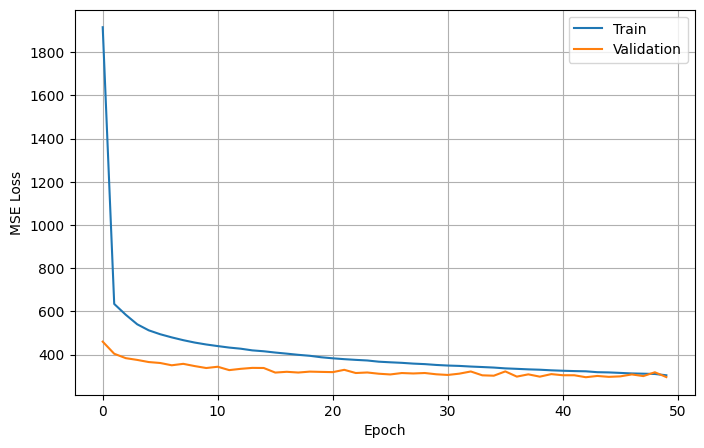

In [8]:
plt.figure(figsize=(8,5))

plt.plot(train_losses,label="Train")
plt.plot(val_losses,label="Validation")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid()

plt.show()

In [9]:
from models.train import evaluate_model, plot_mae, load_vitaldb_test_loader
results = evaluate_model(
    model,
    test_loader,
    device
)


ABSOLUTE ERROR STATISTICS
SBP MAE      : 11.12 mmHg
SBP Variance : 118.24 mmHg²
SBP Std Dev  : 10.87 mmHg

DBP MAE      : 5.95 mmHg
DBP Variance : 40.62 mmHg²
DBP Std Dev  : 6.37 mmHg


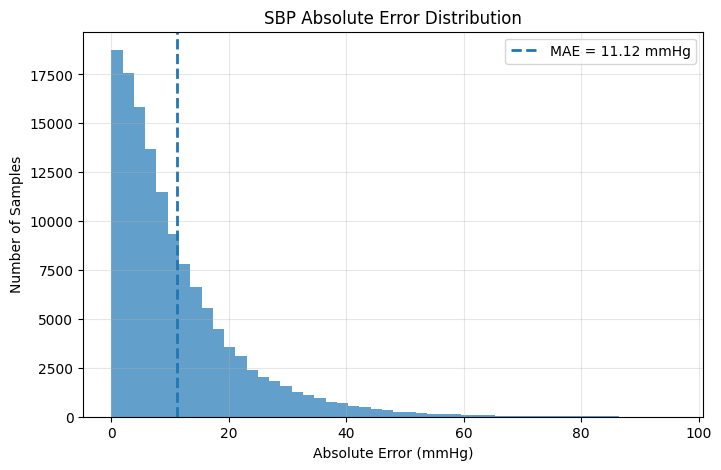

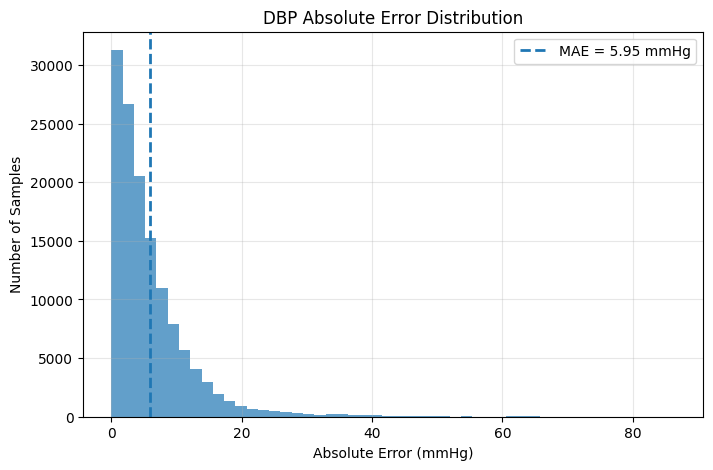


SBP MAE BY TRUE SBP RANGE
60–80 mmHg | Samples:    184 | MAE: 30.82 mmHg
80–100 mmHg | Samples:  10342 | MAE: 15.54 mmHg
100–120 mmHg | Samples:  36971 | MAE: 9.20 mmHg
120–140 mmHg | Samples:  42591 | MAE: 8.22 mmHg
140–160 mmHg | Samples:  29783 | MAE: 11.57 mmHg
160–180 mmHg | Samples:  11086 | MAE: 17.93 mmHg
180–200 mmHg | Samples:   2884 | MAE: 30.53 mmHg
200–220 mmHg | Samples:      0 | MAE: N/A
220–240 mmHg | Samples:      0 | MAE: N/A
240–260 mmHg | Samples:      0 | MAE: N/A


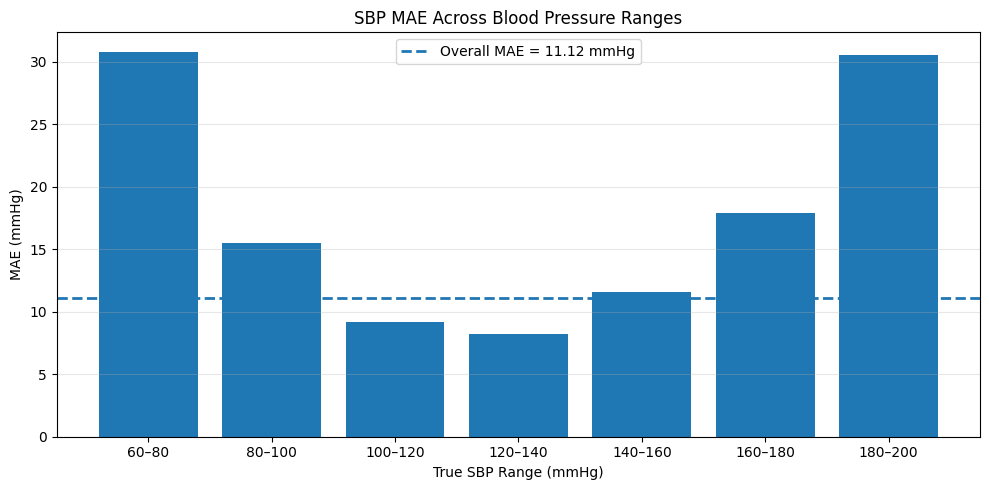


DBP MAE BY TRUE DBP RANGE
20–30 mmHg | Samples:      0 | MAE: N/A
30–40 mmHg | Samples:      0 | MAE: N/A
40–50 mmHg | Samples:      0 | MAE: N/A
50–60 mmHg | Samples:  41517 | MAE: 5.42 mmHg
60–70 mmHg | Samples:  47684 | MAE: 3.86 mmHg
70–80 mmHg | Samples:  26978 | MAE: 5.81 mmHg
80–90 mmHg | Samples:  12397 | MAE: 8.83 mmHg
90–100 mmHg | Samples:   3362 | MAE: 17.01 mmHg
100–110 mmHg | Samples:   1219 | MAE: 27.32 mmHg
110–120 mmHg | Samples:    396 | MAE: 38.34 mmHg
120–130 mmHg | Samples:    186 | MAE: 49.17 mmHg
130–140 mmHg | Samples:     56 | MAE: 55.09 mmHg
140–150 mmHg | Samples:     46 | MAE: 71.75 mmHg


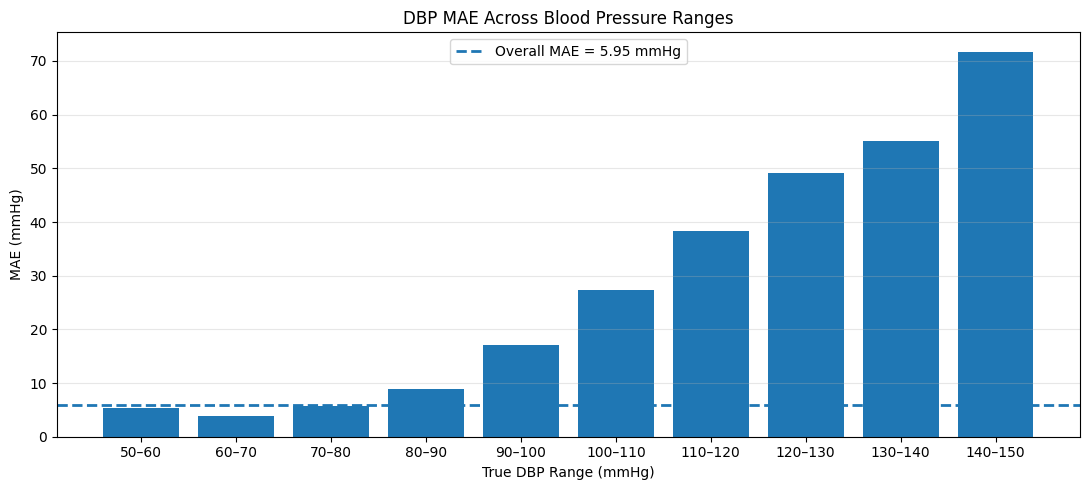

In [10]:
plot_mae(results)

## Zero - shot learning ##

In [18]:
import glob
class VitalDBCheckpointDataset(Dataset):

    def __init__(self, checkpoint_dir):

        self.files = sorted(
            glob.glob(
                os.path.join(
                    checkpoint_dir,
                    "case_*.npz"
                )
            )
        )

        if len(self.files) == 0:
            raise ValueError(
                f"No checkpoint files found in: "
                f"{checkpoint_dir}"
            )

        print(
            "Checkpoint files found:",
            len(self.files)
        )

        # -----------------------------------------
        # Store number of windows in each case
        # -----------------------------------------

        self.lengths = []

        for file_path in self.files:

            data = np.load(file_path)

            self.lengths.append(
                len(data["X"])
            )

        # -----------------------------------------
        # Cumulative lengths
        # -----------------------------------------

        self.cumulative_lengths = np.cumsum(
            self.lengths
        )

        self.total_samples = int(
            self.cumulative_lengths[-1]
        )

        print(
            "Total test windows:",
            self.total_samples
        )

    def __len__(self):

        return self.total_samples

    def __getitem__(self, idx):

        # -----------------------------------------
        # Find which case contains this sample
        # -----------------------------------------

        file_idx = np.searchsorted(
            self.cumulative_lengths,
            idx,
            side="right"
        )

        if file_idx == 0:

            local_idx = idx

        else:

            local_idx = (
                idx -
                self.cumulative_lengths[file_idx - 1]
            )

        file_path = self.files[file_idx]

        # -----------------------------------------
        # Load case
        # -----------------------------------------

        data = np.load(file_path)

        X = data["X"][local_idx]
        y = data["y"][local_idx]

        # -----------------------------------------
        # Add channel dimension
        # (1000,) -> (1, 1000)
        # -----------------------------------------

        X = X[None, :]

        # -----------------------------------------
        # Convert to tensors
        # -----------------------------------------

        X = torch.tensor(
            X,
            dtype=torch.float32
        )

        y = torch.tensor(
            y,
            dtype=torch.float32
        )

        return X, y

from torch.utils.data import Subset

def load_vitaldb_test_loader(
    checkpoint_dir="/data1/yashvi_bhuva/BP_estimation_using_PPG/VitalDB/vitaldb_checkpoints",
    batch_size=1024,
    num_workers=4
):
    test_dataset = VitalDBCheckpointDataset(checkpoint_dir)

    # Take only first 10 samples
    test_dataset = Subset(test_dataset, range(100))

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True
    )
    print("Number of test samples:", len(test_dataset))
    print("Number of test batches:", len(test_loader))
    return test_loader

In [19]:
test_loader = load_vitaldb_test_loader()

results = evaluate_model(
    model,
    test_loader,
    device
)

Checkpoint files found: 3225
Total test windows: 9717359
Number of test samples: 100
Number of test batches: 1



ABSOLUTE ERROR STATISTICS
SBP MAE      : 33.90 mmHg
SBP Variance : 118.44 mmHg²
SBP Std Dev  : 10.88 mmHg

DBP MAE      : 5.10 mmHg
DBP Variance : 15.07 mmHg²
DBP Std Dev  : 3.88 mmHg


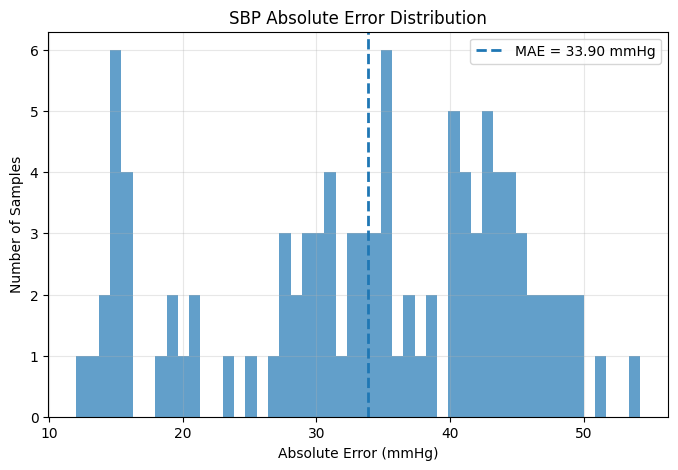

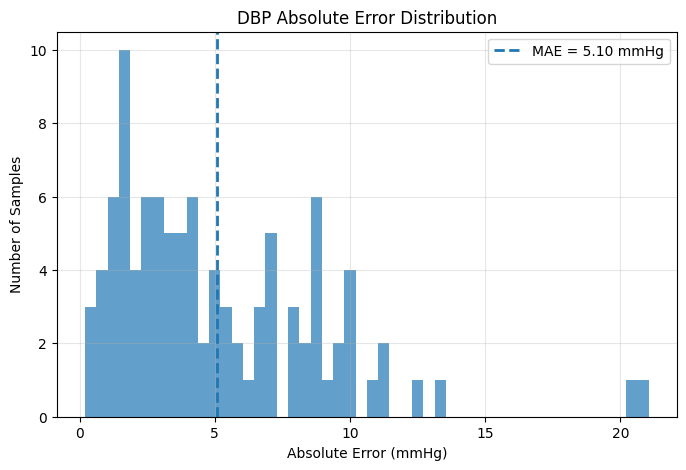


SBP MAE BY TRUE SBP RANGE
60–80 mmHg | Samples:      0 | MAE: N/A
80–100 mmHg | Samples:      0 | MAE: N/A
100–120 mmHg | Samples:      0 | MAE: N/A
120–140 mmHg | Samples:     22 | MAE: 17.11 mmHg
140–160 mmHg | Samples:     38 | MAE: 35.97 mmHg
160–180 mmHg | Samples:     40 | MAE: 41.18 mmHg
180–200 mmHg | Samples:      0 | MAE: N/A
200–220 mmHg | Samples:      0 | MAE: N/A
220–240 mmHg | Samples:      0 | MAE: N/A
240–260 mmHg | Samples:      0 | MAE: N/A


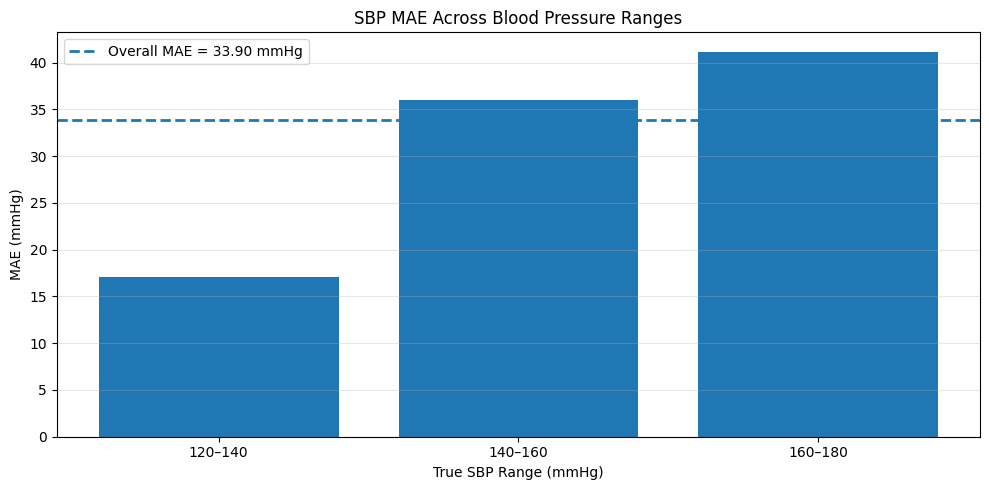


DBP MAE BY TRUE DBP RANGE
20–30 mmHg | Samples:      0 | MAE: N/A
30–40 mmHg | Samples:      0 | MAE: N/A
40–50 mmHg | Samples:      2 | MAE: 20.75 mmHg
50–60 mmHg | Samples:     35 | MAE: 4.22 mmHg
60–70 mmHg | Samples:     35 | MAE: 3.87 mmHg
70–80 mmHg | Samples:     28 | MAE: 6.61 mmHg
80–90 mmHg | Samples:      0 | MAE: N/A
90–100 mmHg | Samples:      0 | MAE: N/A
100–110 mmHg | Samples:      0 | MAE: N/A
110–120 mmHg | Samples:      0 | MAE: N/A
120–130 mmHg | Samples:      0 | MAE: N/A
130–140 mmHg | Samples:      0 | MAE: N/A
140–150 mmHg | Samples:      0 | MAE: N/A


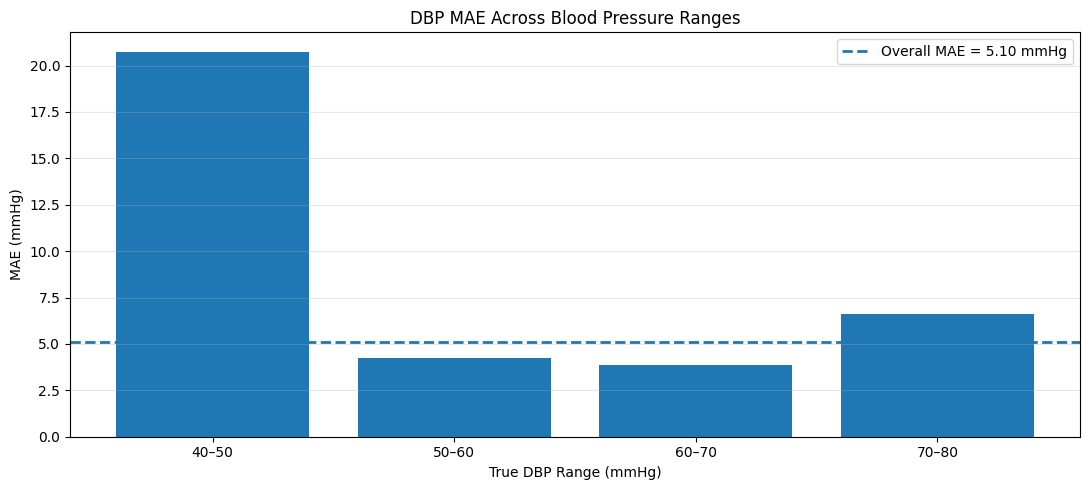

In [20]:
plot_mae(results)

## Adding dialation ##

In [21]:
# -----------------------------
# Dilated Residual Block
# -----------------------------

class DilatedResidualBlock(nn.Module):

    def __init__(self, in_channels, out_channels, stride=1, dilation=1):

        super().__init__()


        self.conv1 = nn.Conv1d(
            in_channels,
            out_channels,
            kernel_size=3,
            stride=stride,
            padding=dilation,
            dilation=dilation,
            bias=False
        )

        self.bn1 = nn.BatchNorm1d(out_channels)


        self.conv2 = nn.Conv1d(
            out_channels,
            out_channels,
            kernel_size=3,
            stride=1,
            padding=dilation,
            dilation=dilation,
            bias=False
        )

        self.bn2 = nn.BatchNorm1d(out_channels)


        self.relu = nn.ReLU()


        # Skip connection
        if stride != 1 or in_channels != out_channels:

            self.shortcut = nn.Sequential(

                nn.Conv1d(
                    in_channels,
                    out_channels,
                    kernel_size=1,
                    stride=stride,
                    bias=False
                ),

                nn.BatchNorm1d(out_channels)
            )

        else:
            self.shortcut = nn.Identity()



    def forward(self, x):

        identity = self.shortcut(x)


        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)


        out = self.conv2(out)
        out = self.bn2(out)


        out += identity

        out = self.relu(out)


        return out



# -----------------------------
# Dilated ResNet1D
# -----------------------------

class ResNet1D_Dilated(nn.Module):

    def __init__(self):

        super().__init__()


        self.stem = nn.Sequential(

            nn.Conv1d(
                1,
                32,
                kernel_size=7,
                stride=2,
                padding=3,
                bias=False
            ),

            nn.BatchNorm1d(32),

            nn.ReLU(),

            nn.MaxPool1d(
                kernel_size=3,
                stride=2,
                padding=1
            )
        )



        self.layer1 = nn.Sequential(

            DilatedResidualBlock(
                32,
                32,
                dilation=1
            ),

            DilatedResidualBlock(
                32,
                32,
                dilation=1
            )
        )



        self.layer2 = nn.Sequential(

            DilatedResidualBlock(
                32,
                64,
                stride=2,
                dilation=2
            ),

            DilatedResidualBlock(
                64,
                64,
                dilation=2
            )
        )



        self.layer3 = nn.Sequential(

            DilatedResidualBlock(
                64,
                128,
                stride=2,
                dilation=4
            ),

            DilatedResidualBlock(
                128,
                128,
                dilation=4
            )
        )



        self.pool = nn.AdaptiveAvgPool1d(1)


        self.fc = nn.Sequential(

            nn.Linear(128,64),

            nn.ReLU(),

            nn.Dropout(0.3),

            nn.Linear(64,2)

        )



    def forward(self,x):

        # x:
        # (batch,1,1000)

        x = self.stem(x)


        x = self.layer1(x)

        x = self.layer2(x)

        x = self.layer3(x)


        x = self.pool(x)


        x = torch.flatten(x,1)


        x = self.fc(x)


        return x

In [22]:
model = ResNet1D_Dilated().to(device)

criterion = nn.MSELoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)


model, history, train_losses, val_losses = train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    epochs=50
)

Epoch 1/50 | Train MSE: 2155.17 (SBP RMSE: 41.27, DBP RMSE: 21.25) | Val MSE: 436.43 (SBP RMSE: 18.44, DBP RMSE: 9.82) | Improved
Epoch 2/50 | Train MSE: 672.93 (SBP RMSE: 22.73, DBP RMSE: 12.51) | Val MSE: 436.84 (SBP RMSE: 18.48, DBP RMSE: 9.77) | No improvement (1/10)
Epoch 3/50 | Train MSE: 608.64 (SBP RMSE: 21.49, DBP RMSE: 12.12) | Val MSE: 392.66 (SBP RMSE: 17.57, DBP RMSE: 9.17) | Improved
Epoch 4/50 | Train MSE: 578.27 (SBP RMSE: 20.83, DBP RMSE: 12.01) | Val MSE: 377.86 (SBP RMSE: 17.12, DBP RMSE: 9.21) | Improved
Epoch 5/50 | Train MSE: 554.60 (SBP RMSE: 20.38, DBP RMSE: 11.80) | Val MSE: 361.57 (SBP RMSE: 16.68, DBP RMSE: 9.13) | Improved
Epoch 6/50 | Train MSE: 532.62 (SBP RMSE: 19.94, DBP RMSE: 11.62) | Val MSE: 359.60 (SBP RMSE: 16.75, DBP RMSE: 8.88) | Improved
Epoch 7/50 | Train MSE: 517.00 (SBP RMSE: 19.62, DBP RMSE: 11.49) | Val MSE: 358.95 (SBP RMSE: 16.73, DBP RMSE: 8.89) | Improved
Epoch 8/50 | Train MSE: 506.15 (SBP RMSE: 19.40, DBP RMSE: 11.39) | Val MSE: 353.81

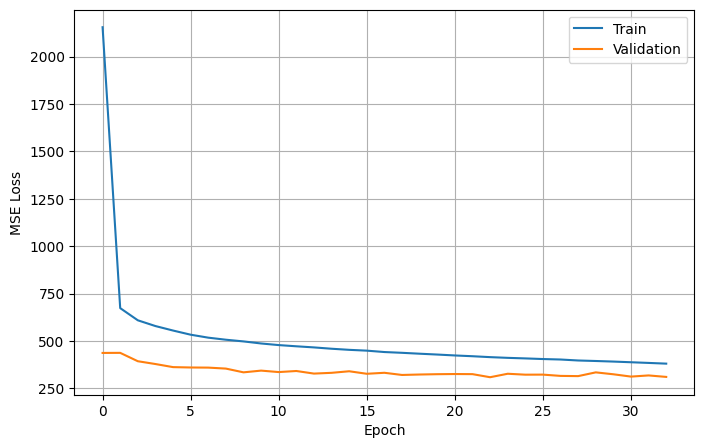

In [23]:
plt.figure(figsize=(8,5))

plt.plot(train_losses,label="Train")
plt.plot(val_losses,label="Validation")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid()

plt.show()

In [24]:
from models.train import evaluate_model
results = evaluate_model(
    model,
    test_loader,
    device
)


ABSOLUTE ERROR STATISTICS
SBP MAE      : 28.93 mmHg
SBP Variance : 118.95 mmHg²
SBP Std Dev  : 10.91 mmHg

DBP MAE      : 6.05 mmHg
DBP Variance : 19.72 mmHg²
DBP Std Dev  : 4.44 mmHg


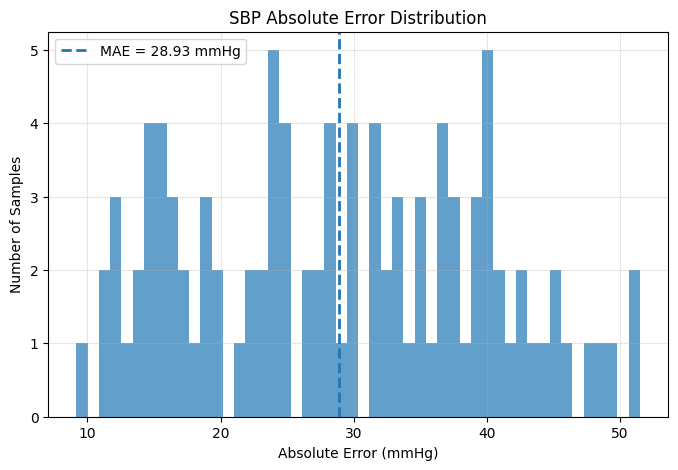

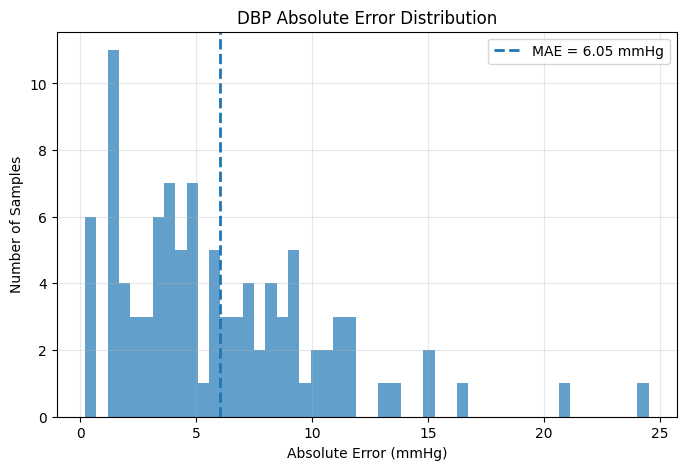


SBP MAE BY TRUE SBP RANGE
60–80 mmHg | Samples:      0 | MAE: N/A
80–100 mmHg | Samples:      0 | MAE: N/A
100–120 mmHg | Samples:      0 | MAE: N/A
120–140 mmHg | Samples:     22 | MAE: 15.59 mmHg
140–160 mmHg | Samples:     38 | MAE: 26.81 mmHg
160–180 mmHg | Samples:     40 | MAE: 38.27 mmHg
180–200 mmHg | Samples:      0 | MAE: N/A
200–220 mmHg | Samples:      0 | MAE: N/A
220–240 mmHg | Samples:      0 | MAE: N/A
240–260 mmHg | Samples:      0 | MAE: N/A


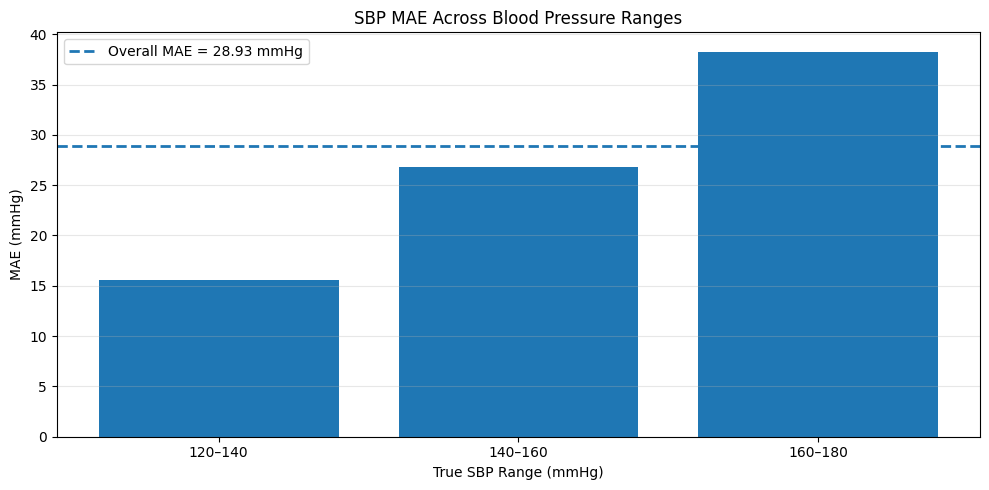


DBP MAE BY TRUE DBP RANGE
20–30 mmHg | Samples:      0 | MAE: N/A
30–40 mmHg | Samples:      0 | MAE: N/A
40–50 mmHg | Samples:      2 | MAE: 22.62 mmHg
50–60 mmHg | Samples:     35 | MAE: 7.56 mmHg
60–70 mmHg | Samples:     35 | MAE: 2.89 mmHg
70–80 mmHg | Samples:     28 | MAE: 6.90 mmHg
80–90 mmHg | Samples:      0 | MAE: N/A
90–100 mmHg | Samples:      0 | MAE: N/A
100–110 mmHg | Samples:      0 | MAE: N/A
110–120 mmHg | Samples:      0 | MAE: N/A
120–130 mmHg | Samples:      0 | MAE: N/A
130–140 mmHg | Samples:      0 | MAE: N/A
140–150 mmHg | Samples:      0 | MAE: N/A


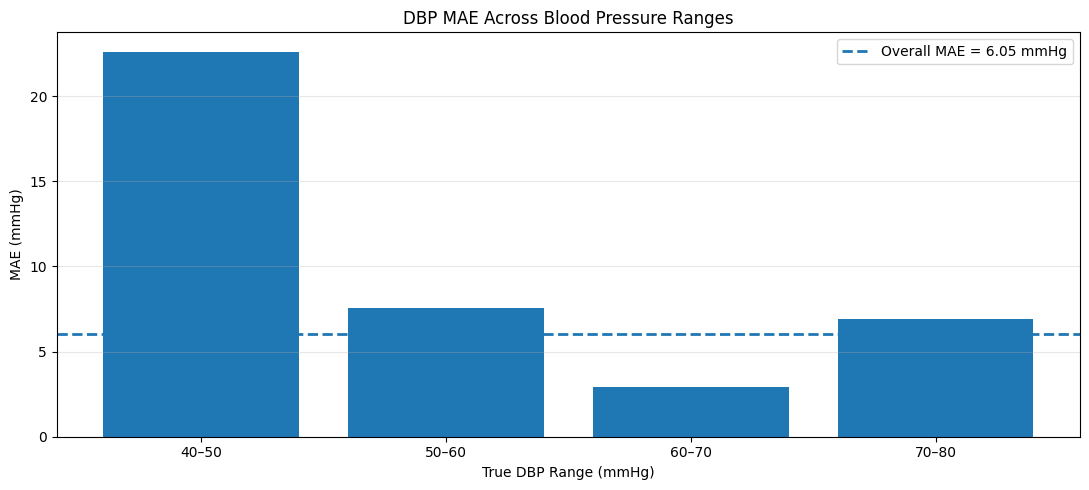

In [25]:
plot_mae(results)

In [26]:
test_loader = load_vitaldb_test_loader()

results = evaluate_model(
    model,
    test_loader,
    device
)

Checkpoint files found: 3225
Total test windows: 9717359
Number of test samples: 100
Number of test batches: 1



ABSOLUTE ERROR STATISTICS
SBP MAE      : 28.93 mmHg
SBP Variance : 118.95 mmHg²
SBP Std Dev  : 10.91 mmHg

DBP MAE      : 6.05 mmHg
DBP Variance : 19.72 mmHg²
DBP Std Dev  : 4.44 mmHg


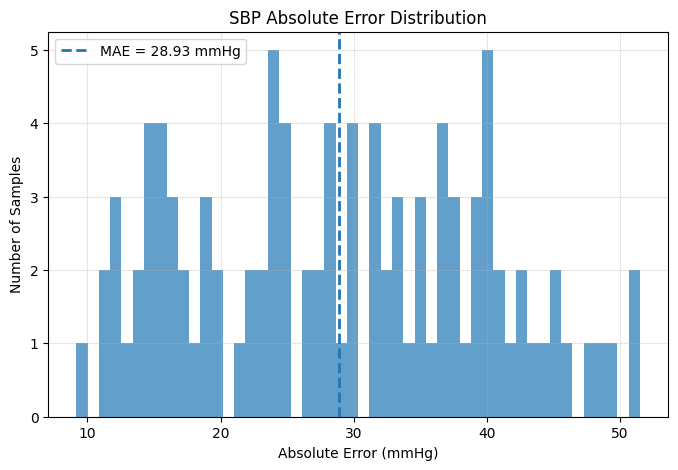

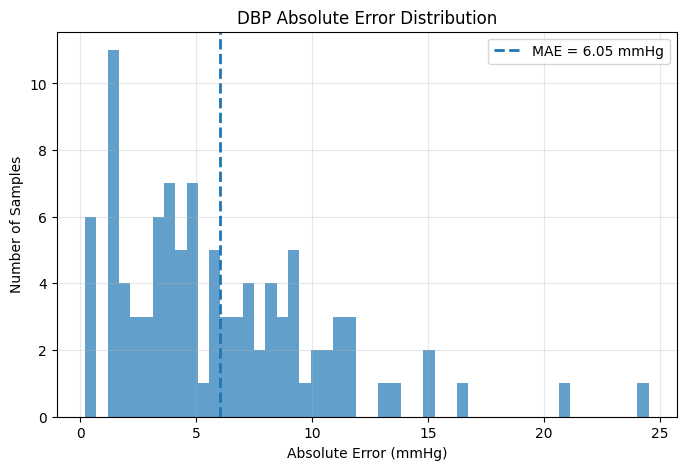


SBP MAE BY TRUE SBP RANGE
60–80 mmHg | Samples:      0 | MAE: N/A
80–100 mmHg | Samples:      0 | MAE: N/A
100–120 mmHg | Samples:      0 | MAE: N/A
120–140 mmHg | Samples:     22 | MAE: 15.59 mmHg
140–160 mmHg | Samples:     38 | MAE: 26.81 mmHg
160–180 mmHg | Samples:     40 | MAE: 38.27 mmHg
180–200 mmHg | Samples:      0 | MAE: N/A
200–220 mmHg | Samples:      0 | MAE: N/A
220–240 mmHg | Samples:      0 | MAE: N/A
240–260 mmHg | Samples:      0 | MAE: N/A


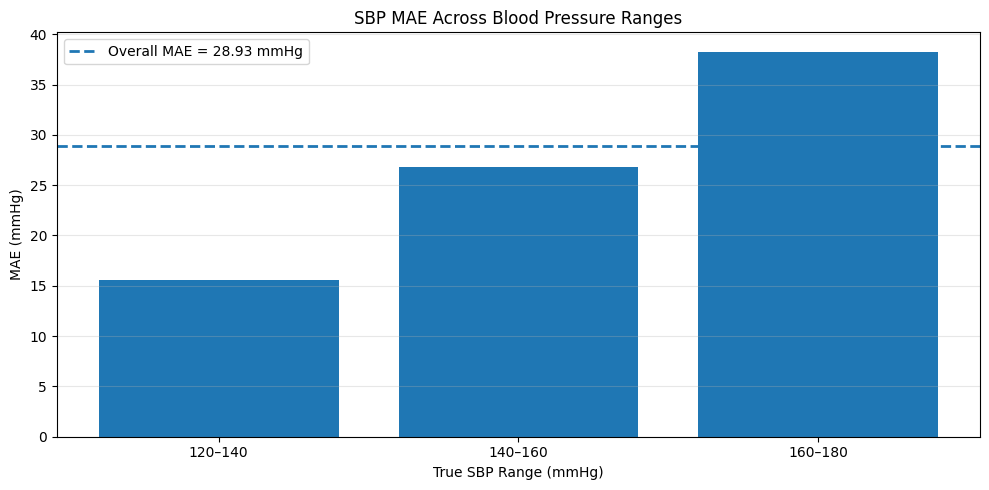


DBP MAE BY TRUE DBP RANGE
20–30 mmHg | Samples:      0 | MAE: N/A
30–40 mmHg | Samples:      0 | MAE: N/A
40–50 mmHg | Samples:      2 | MAE: 22.62 mmHg
50–60 mmHg | Samples:     35 | MAE: 7.56 mmHg
60–70 mmHg | Samples:     35 | MAE: 2.89 mmHg
70–80 mmHg | Samples:     28 | MAE: 6.90 mmHg
80–90 mmHg | Samples:      0 | MAE: N/A
90–100 mmHg | Samples:      0 | MAE: N/A
100–110 mmHg | Samples:      0 | MAE: N/A
110–120 mmHg | Samples:      0 | MAE: N/A
120–130 mmHg | Samples:      0 | MAE: N/A
130–140 mmHg | Samples:      0 | MAE: N/A
140–150 mmHg | Samples:      0 | MAE: N/A


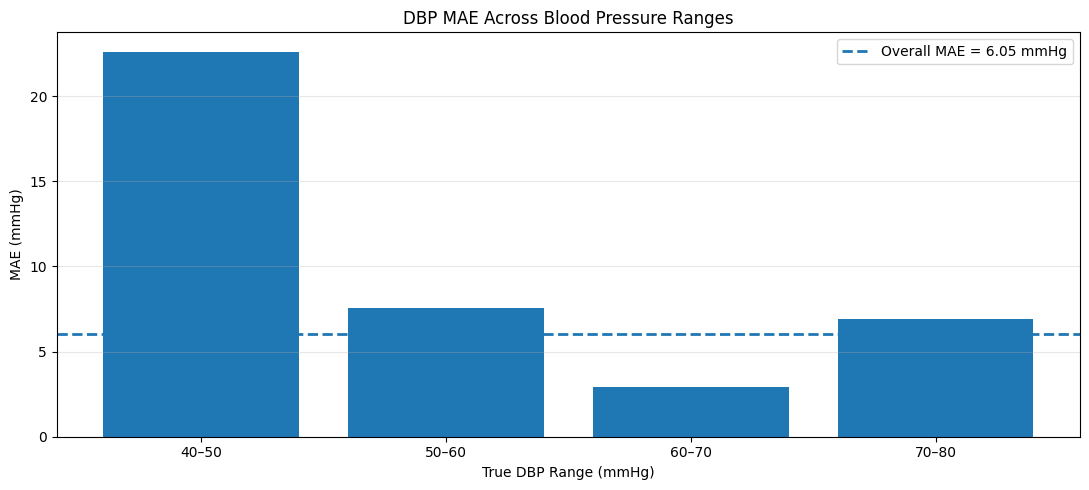

In [27]:
plot_mae(results)

## Adding SE (Squeeze and Excitation) Attention ##

In [28]:
from models.Resnet import SEResNet1D

model = SEResNet1D().to(device)
criterion = nn.MSELoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

In [29]:
from models.train import train_model
model, history, train_losses, val_losses = train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    epochs=50
)

Epoch 1/50 | Train MSE: 2031.12 (SBP RMSE: 40.42, DBP RMSE: 19.93) | Val MSE: 447.10 (SBP RMSE: 18.75, DBP RMSE: 9.78) | Improved
Epoch 2/50 | Train MSE: 642.15 (SBP RMSE: 22.22, DBP RMSE: 12.19) | Val MSE: 438.64 (SBP RMSE: 18.48, DBP RMSE: 9.86) | Improved
Epoch 3/50 | Train MSE: 578.86 (SBP RMSE: 20.95, DBP RMSE: 11.83) | Val MSE: 399.48 (SBP RMSE: 17.59, DBP RMSE: 9.49) | Improved
Epoch 4/50 | Train MSE: 539.20 (SBP RMSE: 20.19, DBP RMSE: 11.48) | Val MSE: 388.55 (SBP RMSE: 17.39, DBP RMSE: 9.28) | Improved
Epoch 5/50 | Train MSE: 510.94 (SBP RMSE: 19.56, DBP RMSE: 11.33) | Val MSE: 370.43 (SBP RMSE: 16.87, DBP RMSE: 9.27) | Improved
Epoch 6/50 | Train MSE: 489.96 (SBP RMSE: 19.10, DBP RMSE: 11.19) | Val MSE: 349.15 (SBP RMSE: 16.37, DBP RMSE: 9.02) | Improved
Epoch 7/50 | Train MSE: 466.19 (SBP RMSE: 18.61, DBP RMSE: 10.95) | Val MSE: 361.95 (SBP RMSE: 16.81, DBP RMSE: 8.91) | No improvement (1/10)
Epoch 8/50 | Train MSE: 450.46 (SBP RMSE: 18.28, DBP RMSE: 10.79) | Val MSE: 347.19

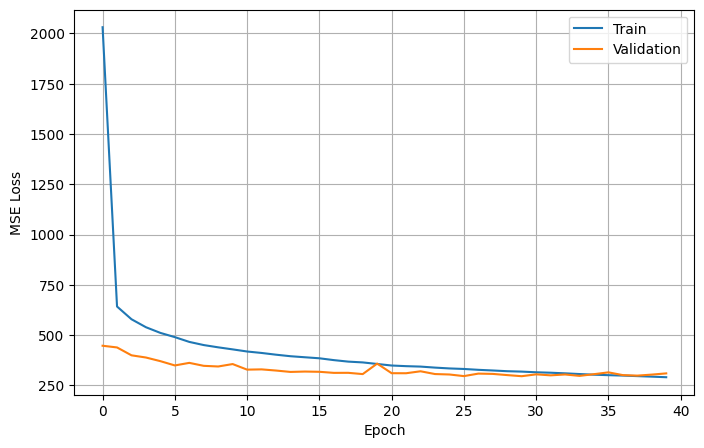

In [30]:
plt.figure(figsize=(8,5))

plt.plot(train_losses,label="Train")
plt.plot(val_losses,label="Validation")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid()

plt.show()

In [31]:
from models.train import evaluate_model
results = evaluate_model(
    model,
    test_loader,
    device
)


ABSOLUTE ERROR STATISTICS
SBP MAE      : 22.59 mmHg
SBP Variance : 167.88 mmHg²
SBP Std Dev  : 12.96 mmHg

DBP MAE      : 9.31 mmHg
DBP Variance : 37.59 mmHg²
DBP Std Dev  : 6.13 mmHg


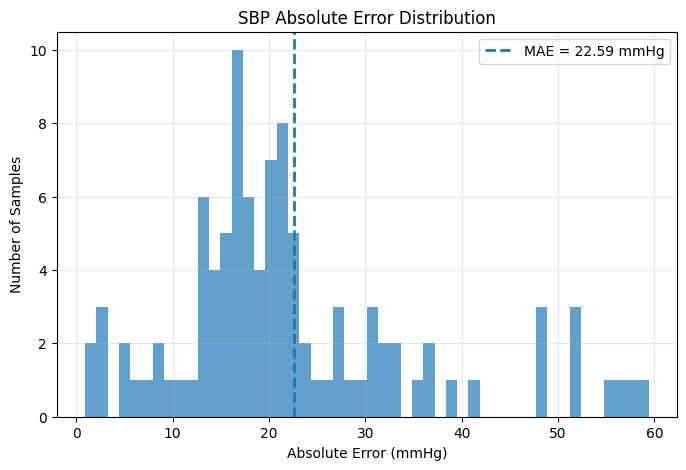

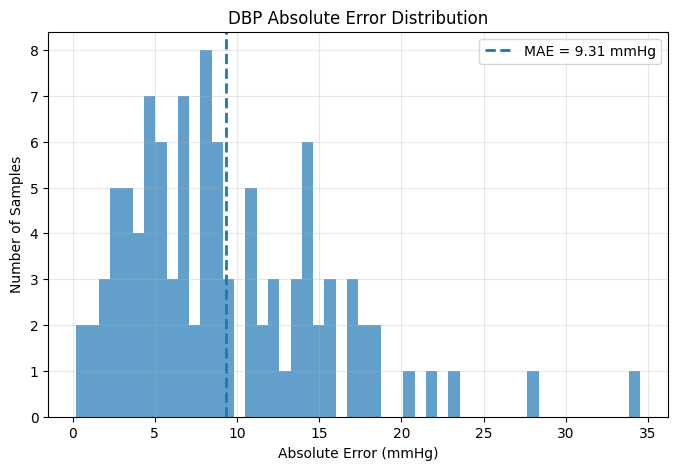


SBP MAE BY TRUE SBP RANGE
60–80 mmHg | Samples:      0 | MAE: N/A
80–100 mmHg | Samples:      0 | MAE: N/A
100–120 mmHg | Samples:      0 | MAE: N/A
120–140 mmHg | Samples:     22 | MAE: 17.39 mmHg
140–160 mmHg | Samples:     38 | MAE: 18.32 mmHg
160–180 mmHg | Samples:     40 | MAE: 29.50 mmHg
180–200 mmHg | Samples:      0 | MAE: N/A
200–220 mmHg | Samples:      0 | MAE: N/A
220–240 mmHg | Samples:      0 | MAE: N/A
240–260 mmHg | Samples:      0 | MAE: N/A


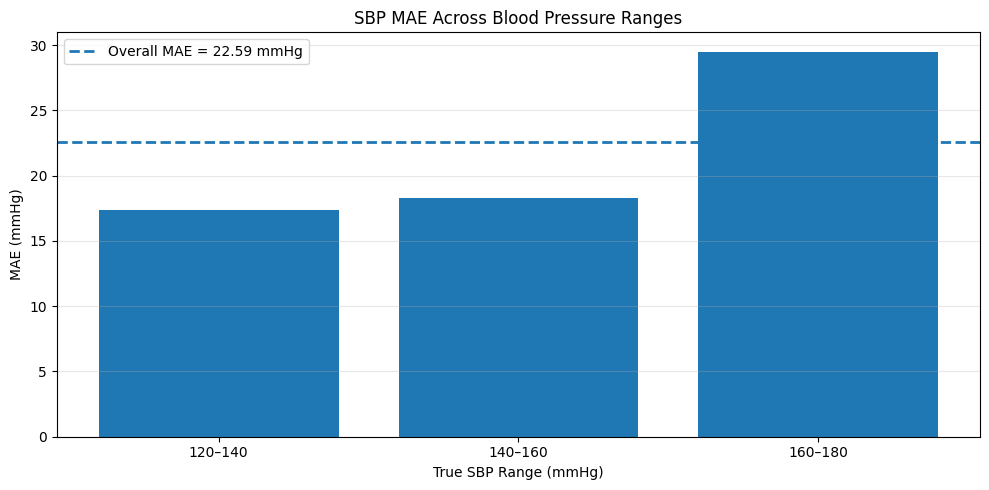


DBP MAE BY TRUE DBP RANGE
20–30 mmHg | Samples:      0 | MAE: N/A
30–40 mmHg | Samples:      0 | MAE: N/A
40–50 mmHg | Samples:      2 | MAE: 31.24 mmHg
50–60 mmHg | Samples:     35 | MAE: 8.91 mmHg
60–70 mmHg | Samples:     35 | MAE: 11.45 mmHg
70–80 mmHg | Samples:     28 | MAE: 5.56 mmHg
80–90 mmHg | Samples:      0 | MAE: N/A
90–100 mmHg | Samples:      0 | MAE: N/A
100–110 mmHg | Samples:      0 | MAE: N/A
110–120 mmHg | Samples:      0 | MAE: N/A
120–130 mmHg | Samples:      0 | MAE: N/A
130–140 mmHg | Samples:      0 | MAE: N/A
140–150 mmHg | Samples:      0 | MAE: N/A


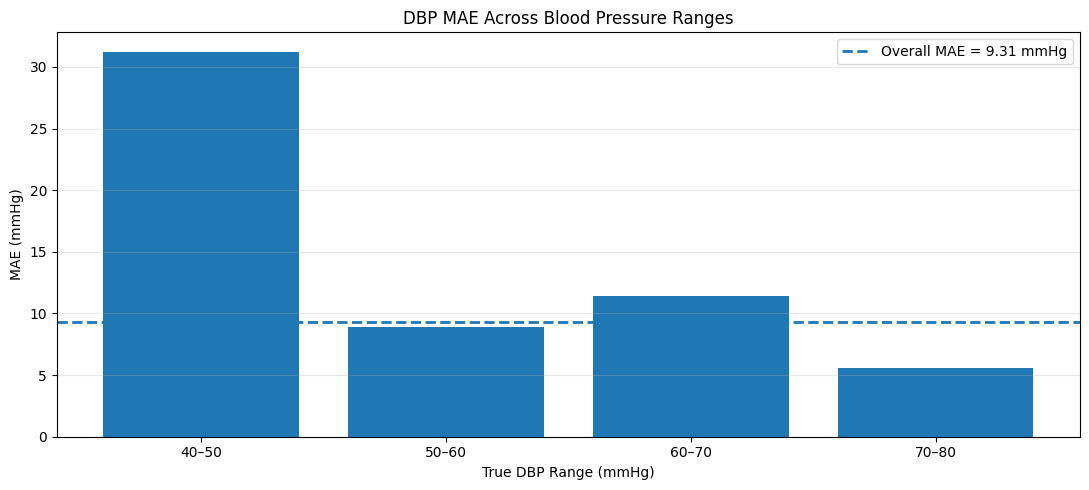

In [32]:
plot_mae(results)

In [33]:
test_loader = load_vitaldb_test_loader()

results = evaluate_model(
    model,
    test_loader,
    device
)

Checkpoint files found: 3225
Total test windows: 9717359
Number of test samples: 100
Number of test batches: 1



ABSOLUTE ERROR STATISTICS
SBP MAE      : 22.59 mmHg
SBP Variance : 167.88 mmHg²
SBP Std Dev  : 12.96 mmHg

DBP MAE      : 9.31 mmHg
DBP Variance : 37.59 mmHg²
DBP Std Dev  : 6.13 mmHg


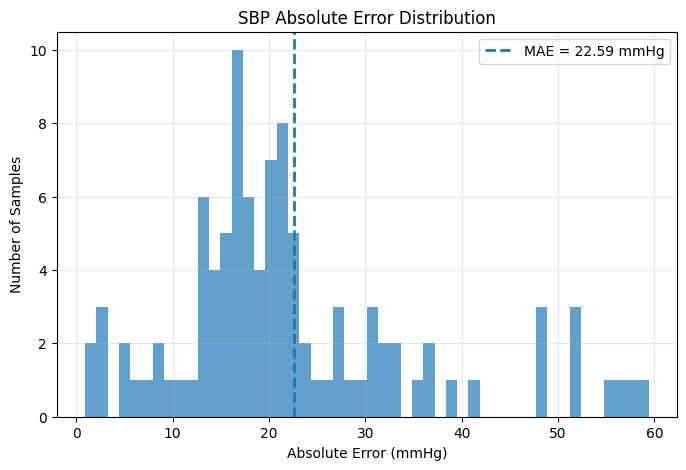

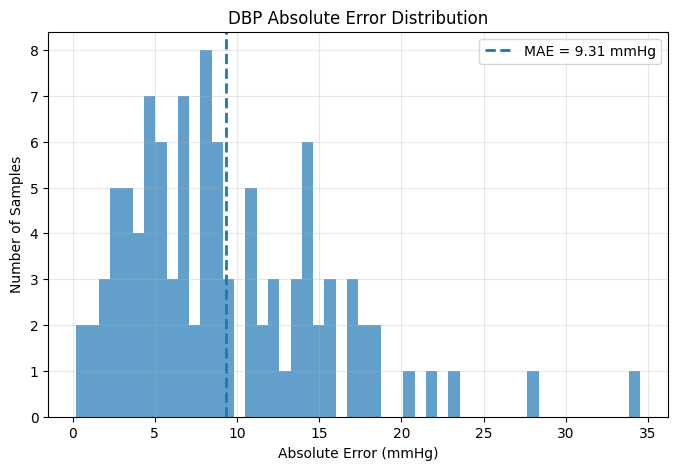


SBP MAE BY TRUE SBP RANGE
60–80 mmHg | Samples:      0 | MAE: N/A
80–100 mmHg | Samples:      0 | MAE: N/A
100–120 mmHg | Samples:      0 | MAE: N/A
120–140 mmHg | Samples:     22 | MAE: 17.39 mmHg
140–160 mmHg | Samples:     38 | MAE: 18.32 mmHg
160–180 mmHg | Samples:     40 | MAE: 29.50 mmHg
180–200 mmHg | Samples:      0 | MAE: N/A
200–220 mmHg | Samples:      0 | MAE: N/A
220–240 mmHg | Samples:      0 | MAE: N/A
240–260 mmHg | Samples:      0 | MAE: N/A


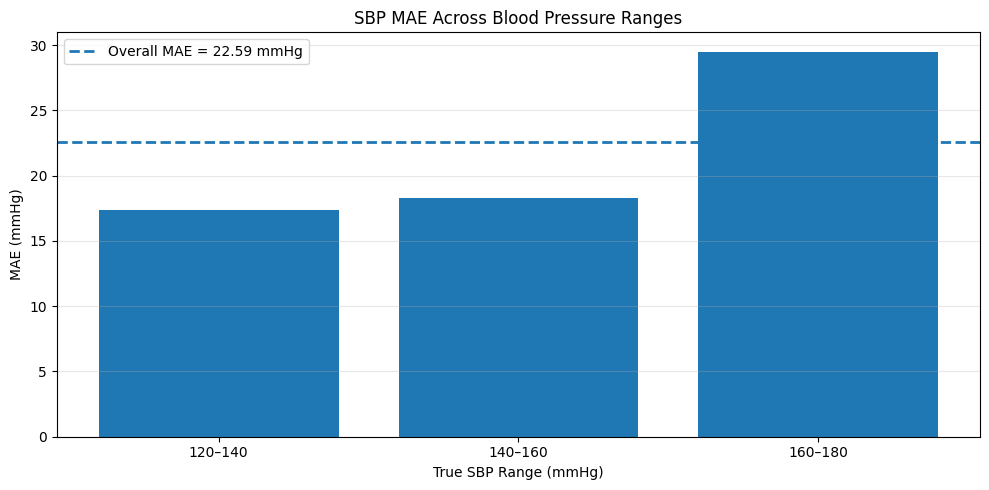


DBP MAE BY TRUE DBP RANGE
20–30 mmHg | Samples:      0 | MAE: N/A
30–40 mmHg | Samples:      0 | MAE: N/A
40–50 mmHg | Samples:      2 | MAE: 31.24 mmHg
50–60 mmHg | Samples:     35 | MAE: 8.91 mmHg
60–70 mmHg | Samples:     35 | MAE: 11.45 mmHg
70–80 mmHg | Samples:     28 | MAE: 5.56 mmHg
80–90 mmHg | Samples:      0 | MAE: N/A
90–100 mmHg | Samples:      0 | MAE: N/A
100–110 mmHg | Samples:      0 | MAE: N/A
110–120 mmHg | Samples:      0 | MAE: N/A
120–130 mmHg | Samples:      0 | MAE: N/A
130–140 mmHg | Samples:      0 | MAE: N/A
140–150 mmHg | Samples:      0 | MAE: N/A


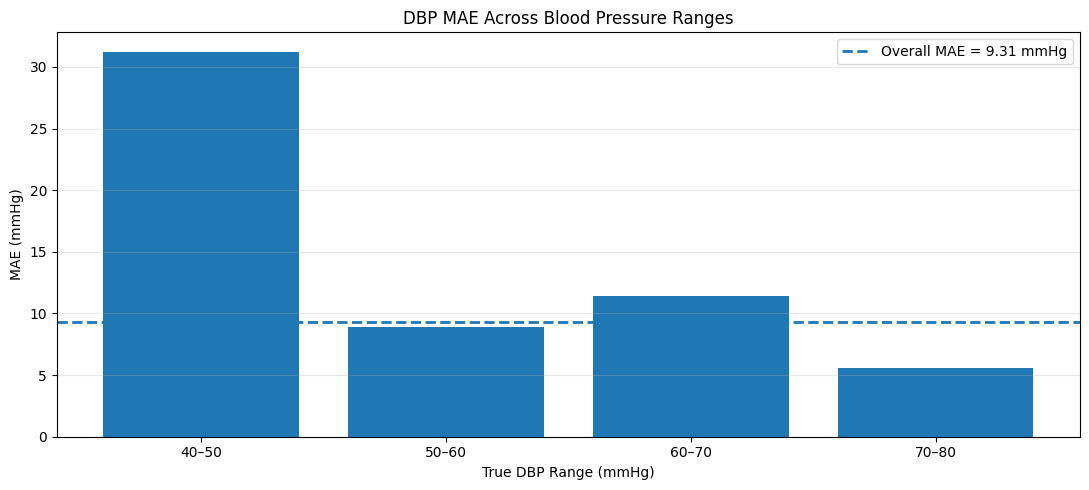

In [34]:
plot_mae(results)

## Using ResNet18 ##

In [35]:
from models.Resnet import ResNet18_1D

model = ResNet18_1D().to(device)
criterion = nn.MSELoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

In [36]:
model, history, train_losses, val_losses = train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    epochs=50
)

Epoch 1/50 | Train MSE: 1874.70 (SBP RMSE: 39.63, DBP RMSE: 17.44) | Val MSE: 417.26 (SBP RMSE: 18.28, DBP RMSE: 9.11) | Improved
Epoch 2/50 | Train MSE: 290.06 (SBP RMSE: 14.76, DBP RMSE: 8.50) | Val MSE: 334.63 (SBP RMSE: 16.07, DBP RMSE: 8.74) | Improved
Epoch 3/50 | Train MSE: 236.67 (SBP RMSE: 13.22, DBP RMSE: 7.86) | Val MSE: 319.06 (SBP RMSE: 15.82, DBP RMSE: 8.30) | Improved
Epoch 4/50 | Train MSE: 205.86 (SBP RMSE: 12.25, DBP RMSE: 7.47) | Val MSE: 316.77 (SBP RMSE: 15.66, DBP RMSE: 8.46) | Improved
Epoch 5/50 | Train MSE: 185.45 (SBP RMSE: 11.58, DBP RMSE: 7.17) | Val MSE: 293.40 (SBP RMSE: 14.98, DBP RMSE: 8.31) | Improved
Epoch 6/50 | Train MSE: 169.72 (SBP RMSE: 11.02, DBP RMSE: 6.95) | Val MSE: 314.69 (SBP RMSE: 15.40, DBP RMSE: 8.81) | No improvement (1/10)
Epoch 7/50 | Train MSE: 157.44 (SBP RMSE: 10.57, DBP RMSE: 6.75) | Val MSE: 299.90 (SBP RMSE: 15.18, DBP RMSE: 8.34) | No improvement (2/10)
Epoch 8/50 | Train MSE: 146.60 (SBP RMSE: 10.17, DBP RMSE: 6.58) | Val MSE: 

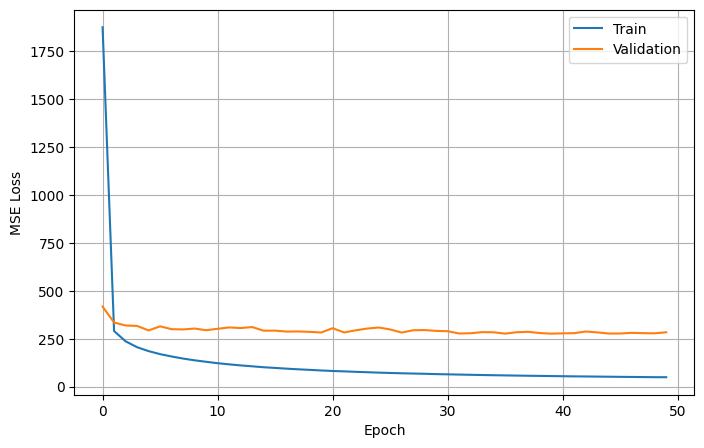

In [37]:
plt.figure(figsize=(8,5))

plt.plot(train_losses,label="Train")
plt.plot(val_losses,label="Validation")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid()

plt.show()

In [38]:
from models.train import evaluate_model
results = evaluate_model(
    model,
    test_loader,
    device
)


ABSOLUTE ERROR STATISTICS
SBP MAE      : 16.24 mmHg
SBP Variance : 135.47 mmHg²
SBP Std Dev  : 11.64 mmHg

DBP MAE      : 11.65 mmHg
DBP Variance : 77.45 mmHg²
DBP Std Dev  : 8.80 mmHg


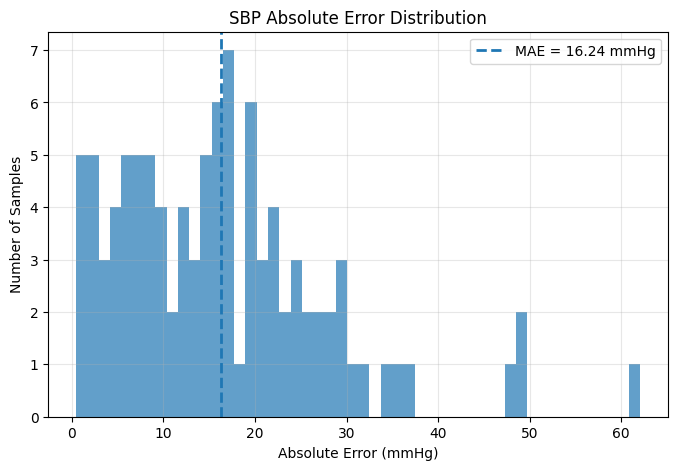

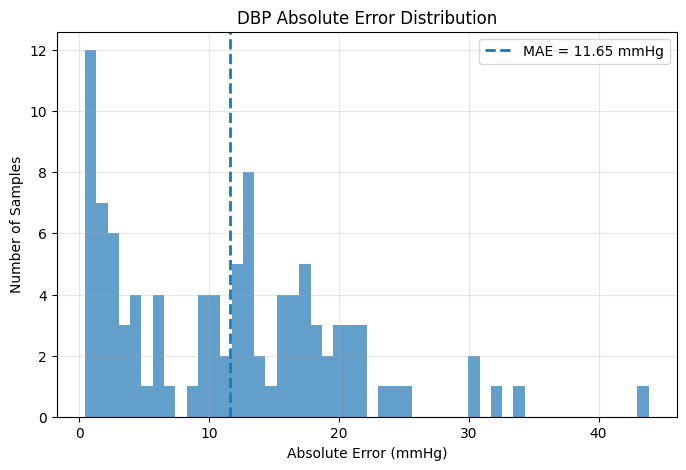


SBP MAE BY TRUE SBP RANGE
60–80 mmHg | Samples:      0 | MAE: N/A
80–100 mmHg | Samples:      0 | MAE: N/A
100–120 mmHg | Samples:      0 | MAE: N/A
120–140 mmHg | Samples:     22 | MAE: 18.78 mmHg
140–160 mmHg | Samples:     38 | MAE: 14.71 mmHg
160–180 mmHg | Samples:     40 | MAE: 16.29 mmHg
180–200 mmHg | Samples:      0 | MAE: N/A
200–220 mmHg | Samples:      0 | MAE: N/A
220–240 mmHg | Samples:      0 | MAE: N/A
240–260 mmHg | Samples:      0 | MAE: N/A


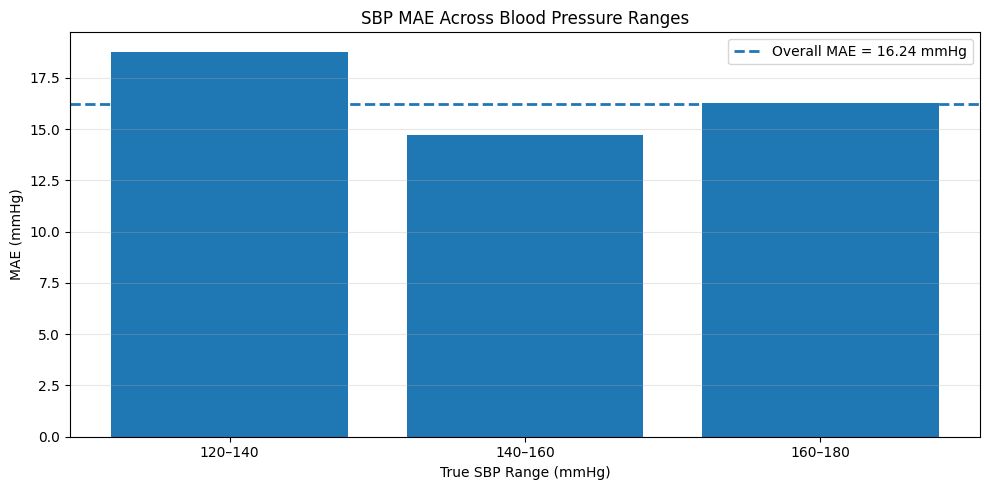


DBP MAE BY TRUE DBP RANGE
20–30 mmHg | Samples:      0 | MAE: N/A
30–40 mmHg | Samples:      0 | MAE: N/A
40–50 mmHg | Samples:      2 | MAE: 31.98 mmHg
50–60 mmHg | Samples:     35 | MAE: 9.45 mmHg
60–70 mmHg | Samples:     35 | MAE: 12.77 mmHg
70–80 mmHg | Samples:     28 | MAE: 11.55 mmHg
80–90 mmHg | Samples:      0 | MAE: N/A
90–100 mmHg | Samples:      0 | MAE: N/A
100–110 mmHg | Samples:      0 | MAE: N/A
110–120 mmHg | Samples:      0 | MAE: N/A
120–130 mmHg | Samples:      0 | MAE: N/A
130–140 mmHg | Samples:      0 | MAE: N/A
140–150 mmHg | Samples:      0 | MAE: N/A


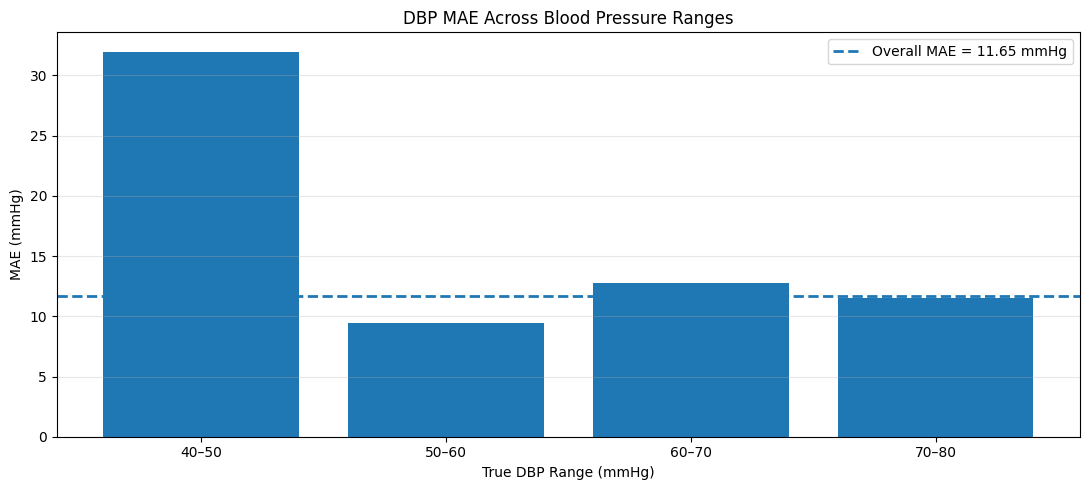

In [39]:
plot_mae(results)

In [40]:
test_loader = load_vitaldb_test_loader()

results = evaluate_model(
    model,
    test_loader,
    device
)

Checkpoint files found: 3225
Total test windows: 9717359
Number of test samples: 100
Number of test batches: 1



ABSOLUTE ERROR STATISTICS
SBP MAE      : 16.24 mmHg
SBP Variance : 135.47 mmHg²
SBP Std Dev  : 11.64 mmHg

DBP MAE      : 11.65 mmHg
DBP Variance : 77.45 mmHg²
DBP Std Dev  : 8.80 mmHg


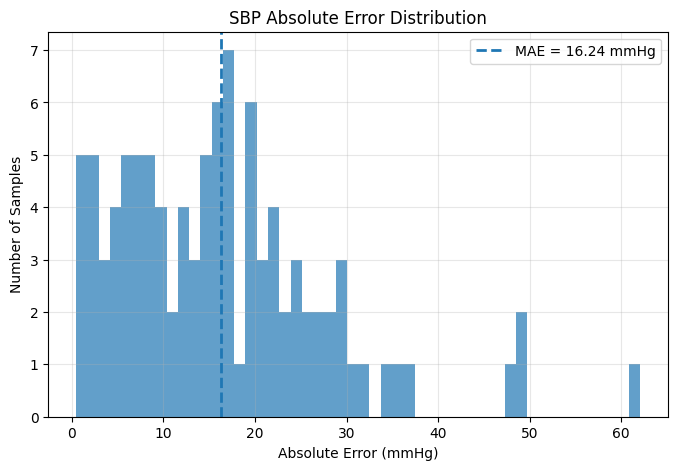

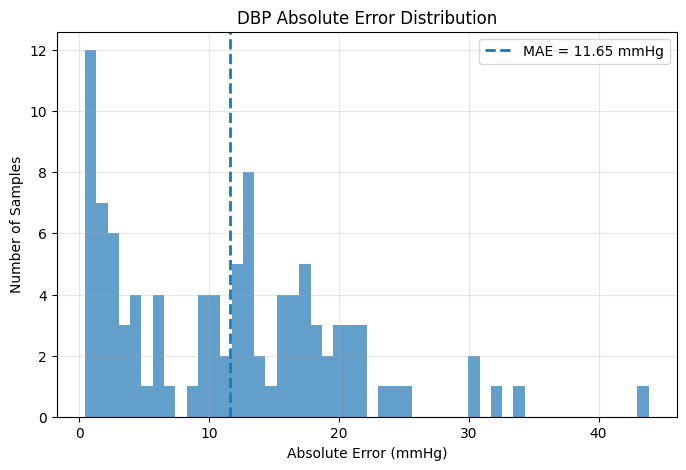


SBP MAE BY TRUE SBP RANGE
60–80 mmHg | Samples:      0 | MAE: N/A
80–100 mmHg | Samples:      0 | MAE: N/A
100–120 mmHg | Samples:      0 | MAE: N/A
120–140 mmHg | Samples:     22 | MAE: 18.78 mmHg
140–160 mmHg | Samples:     38 | MAE: 14.71 mmHg
160–180 mmHg | Samples:     40 | MAE: 16.29 mmHg
180–200 mmHg | Samples:      0 | MAE: N/A
200–220 mmHg | Samples:      0 | MAE: N/A
220–240 mmHg | Samples:      0 | MAE: N/A
240–260 mmHg | Samples:      0 | MAE: N/A


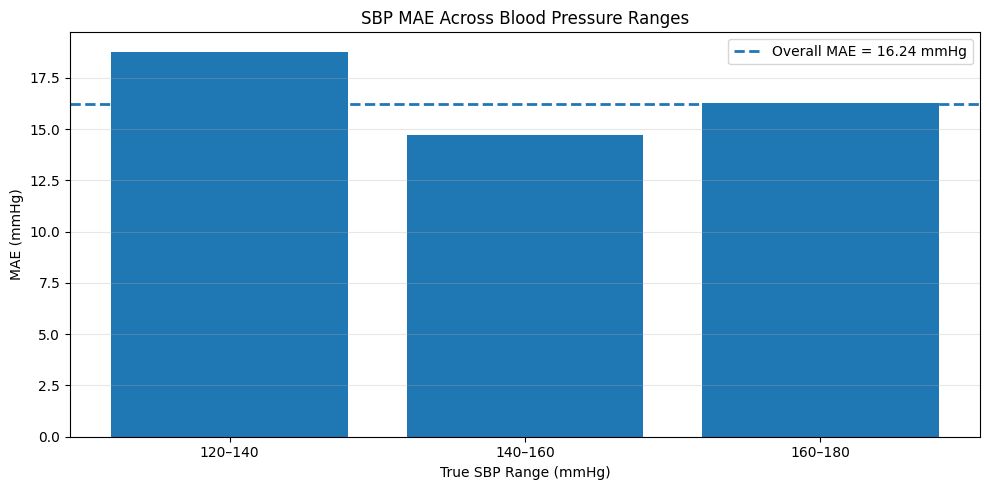


DBP MAE BY TRUE DBP RANGE
20–30 mmHg | Samples:      0 | MAE: N/A
30–40 mmHg | Samples:      0 | MAE: N/A
40–50 mmHg | Samples:      2 | MAE: 31.98 mmHg
50–60 mmHg | Samples:     35 | MAE: 9.45 mmHg
60–70 mmHg | Samples:     35 | MAE: 12.77 mmHg
70–80 mmHg | Samples:     28 | MAE: 11.55 mmHg
80–90 mmHg | Samples:      0 | MAE: N/A
90–100 mmHg | Samples:      0 | MAE: N/A
100–110 mmHg | Samples:      0 | MAE: N/A
110–120 mmHg | Samples:      0 | MAE: N/A
120–130 mmHg | Samples:      0 | MAE: N/A
130–140 mmHg | Samples:      0 | MAE: N/A
140–150 mmHg | Samples:      0 | MAE: N/A


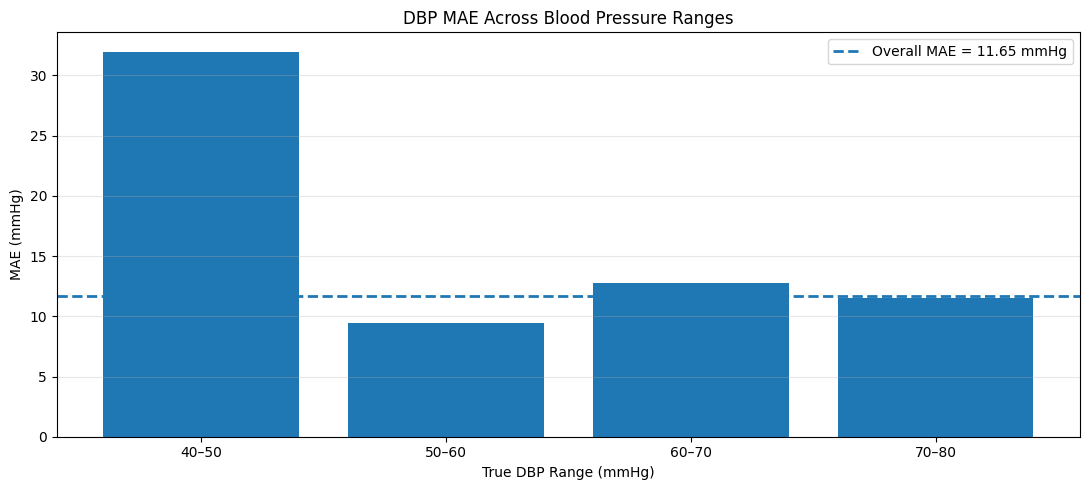

In [41]:
plot_mae(results)

## ResNet18 + SE Attention ##

In [42]:
from models.Resnet import SEResNet18_1D

model = SEResNet18_1D().to(device)
criterion = nn.MSELoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

In [43]:
model, history, train_losses, val_losses = train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    epochs=50
)

Epoch 1/50 | Train MSE: 1917.00 (SBP RMSE: 40.23, DBP RMSE: 17.28) | Val MSE: 430.63 (SBP RMSE: 18.59, DBP RMSE: 9.23) | Improved
Epoch 2/50 | Train MSE: 344.51 (SBP RMSE: 16.16, DBP RMSE: 9.12) | Val MSE: 356.77 (SBP RMSE: 16.75, DBP RMSE: 8.73) | Improved
Epoch 3/50 | Train MSE: 263.27 (SBP RMSE: 13.98, DBP RMSE: 8.24) | Val MSE: 311.92 (SBP RMSE: 15.64, DBP RMSE: 8.21) | Improved
Epoch 4/50 | Train MSE: 218.86 (SBP RMSE: 12.64, DBP RMSE: 7.68) | Val MSE: 307.81 (SBP RMSE: 15.36, DBP RMSE: 8.49) | Improved
Epoch 5/50 | Train MSE: 190.74 (SBP RMSE: 11.74, DBP RMSE: 7.28) | Val MSE: 304.63 (SBP RMSE: 15.41, DBP RMSE: 8.20) | Improved
Epoch 6/50 | Train MSE: 170.92 (SBP RMSE: 11.05, DBP RMSE: 6.98) | Val MSE: 298.70 (SBP RMSE: 15.21, DBP RMSE: 8.20) | Improved
Epoch 7/50 | Train MSE: 155.27 (SBP RMSE: 10.49, DBP RMSE: 6.72) | Val MSE: 287.92 (SBP RMSE: 14.92, DBP RMSE: 8.08) | Improved
Epoch 8/50 | Train MSE: 142.88 (SBP RMSE: 10.03, DBP RMSE: 6.50) | Val MSE: 277.72 (SBP RMSE: 14.53, D

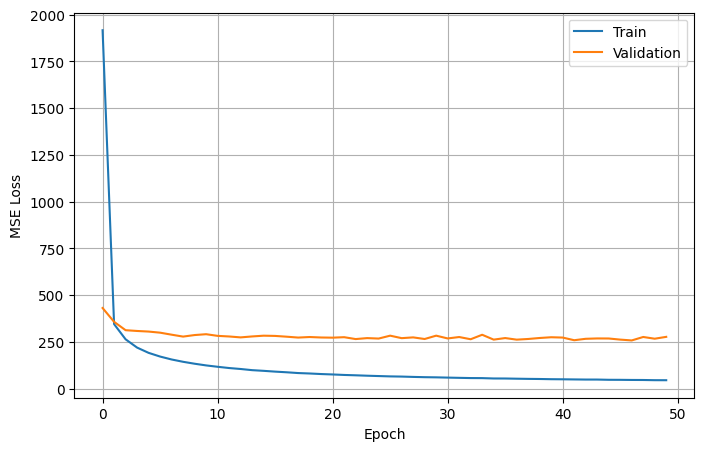

In [44]:
plt.figure(figsize=(8,5))

plt.plot(train_losses,label="Train")
plt.plot(val_losses,label="Validation")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid()

plt.show()

In [45]:
from models.train import evaluate_model
results = evaluate_model(
    model,
    test_loader,
    device
)


ABSOLUTE ERROR STATISTICS
SBP MAE      : 29.65 mmHg
SBP Variance : 217.76 mmHg²
SBP Std Dev  : 14.76 mmHg

DBP MAE      : 6.11 mmHg
DBP Variance : 18.24 mmHg²
DBP Std Dev  : 4.27 mmHg


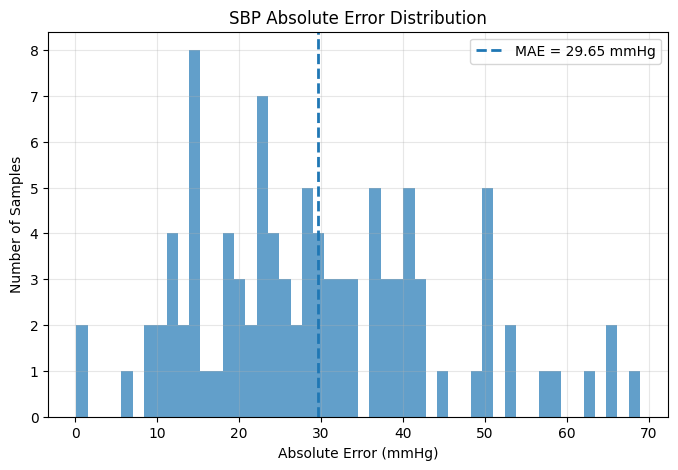

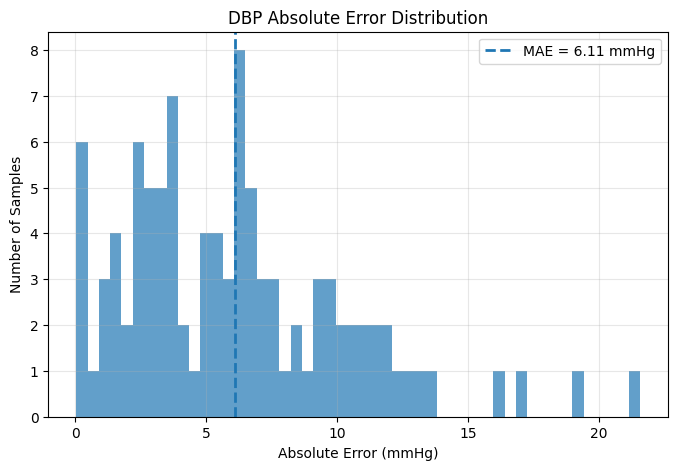


SBP MAE BY TRUE SBP RANGE
60–80 mmHg | Samples:      0 | MAE: N/A
80–100 mmHg | Samples:      0 | MAE: N/A
100–120 mmHg | Samples:      0 | MAE: N/A
120–140 mmHg | Samples:     22 | MAE: 14.96 mmHg
140–160 mmHg | Samples:     38 | MAE: 28.69 mmHg
160–180 mmHg | Samples:     40 | MAE: 38.65 mmHg
180–200 mmHg | Samples:      0 | MAE: N/A
200–220 mmHg | Samples:      0 | MAE: N/A
220–240 mmHg | Samples:      0 | MAE: N/A
240–260 mmHg | Samples:      0 | MAE: N/A


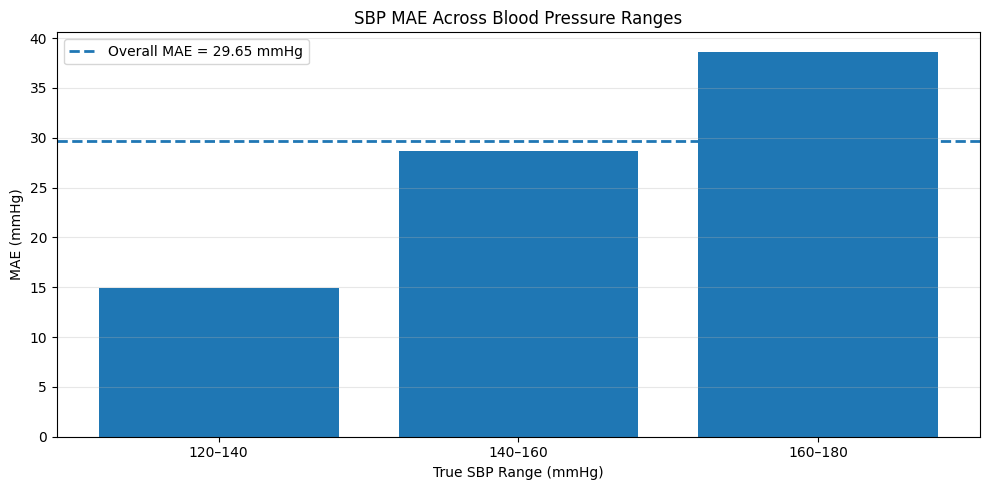


DBP MAE BY TRUE DBP RANGE
20–30 mmHg | Samples:      0 | MAE: N/A
30–40 mmHg | Samples:      0 | MAE: N/A
40–50 mmHg | Samples:      2 | MAE: 20.40 mmHg
50–60 mmHg | Samples:     35 | MAE: 5.24 mmHg
60–70 mmHg | Samples:     35 | MAE: 4.04 mmHg
70–80 mmHg | Samples:     28 | MAE: 8.77 mmHg
80–90 mmHg | Samples:      0 | MAE: N/A
90–100 mmHg | Samples:      0 | MAE: N/A
100–110 mmHg | Samples:      0 | MAE: N/A
110–120 mmHg | Samples:      0 | MAE: N/A
120–130 mmHg | Samples:      0 | MAE: N/A
130–140 mmHg | Samples:      0 | MAE: N/A
140–150 mmHg | Samples:      0 | MAE: N/A


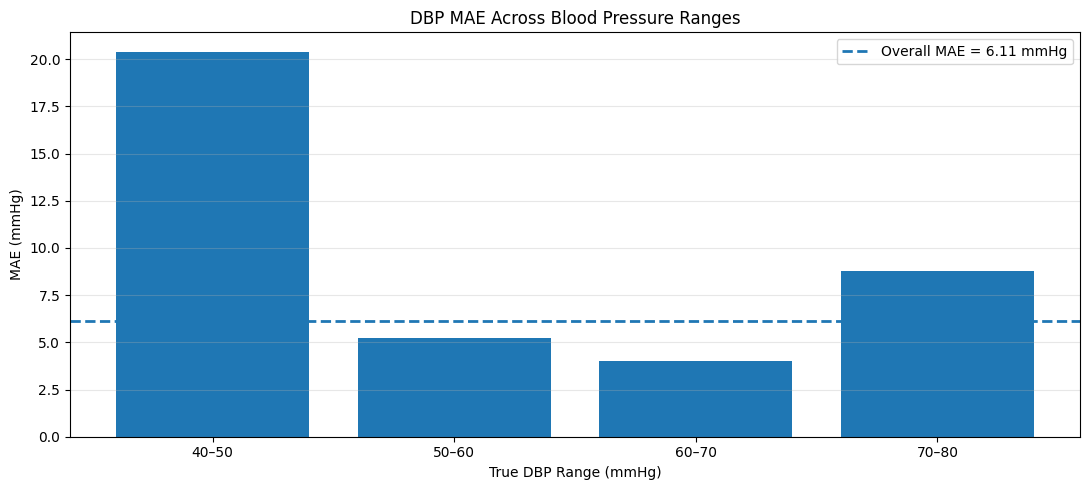

In [46]:
plot_mae(results)

In [47]:
test_loader = load_vitaldb_test_loader()

results = evaluate_model(
    model,
    test_loader,
    device
)

Checkpoint files found: 3225
Total test windows: 9717359
Number of test samples: 100
Number of test batches: 1



ABSOLUTE ERROR STATISTICS
SBP MAE      : 29.65 mmHg
SBP Variance : 217.76 mmHg²
SBP Std Dev  : 14.76 mmHg

DBP MAE      : 6.11 mmHg
DBP Variance : 18.24 mmHg²
DBP Std Dev  : 4.27 mmHg


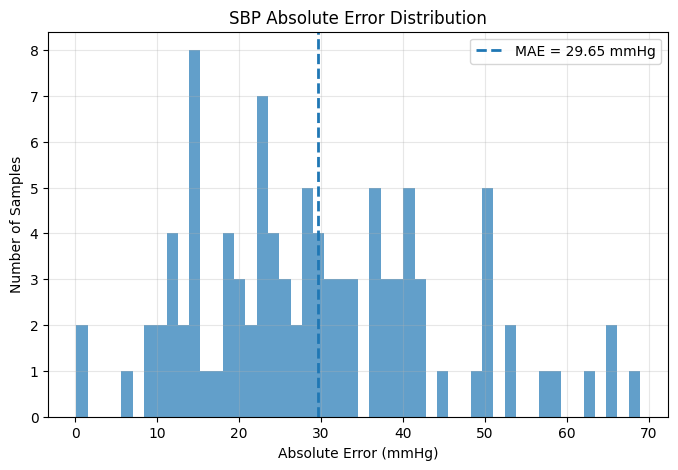

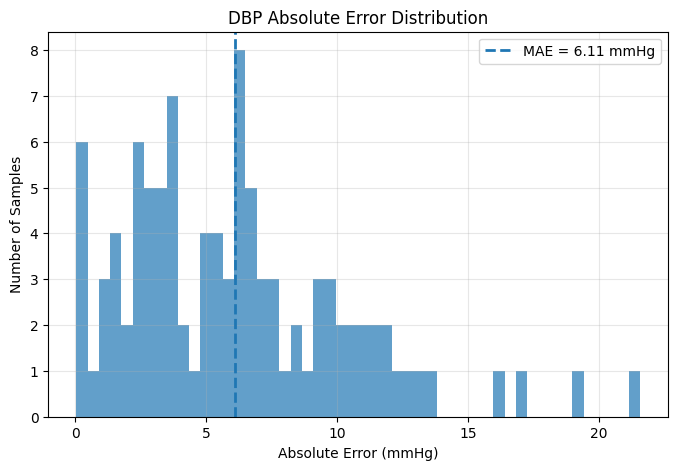


SBP MAE BY TRUE SBP RANGE
60–80 mmHg | Samples:      0 | MAE: N/A
80–100 mmHg | Samples:      0 | MAE: N/A
100–120 mmHg | Samples:      0 | MAE: N/A
120–140 mmHg | Samples:     22 | MAE: 14.96 mmHg
140–160 mmHg | Samples:     38 | MAE: 28.69 mmHg
160–180 mmHg | Samples:     40 | MAE: 38.65 mmHg
180–200 mmHg | Samples:      0 | MAE: N/A
200–220 mmHg | Samples:      0 | MAE: N/A
220–240 mmHg | Samples:      0 | MAE: N/A
240–260 mmHg | Samples:      0 | MAE: N/A


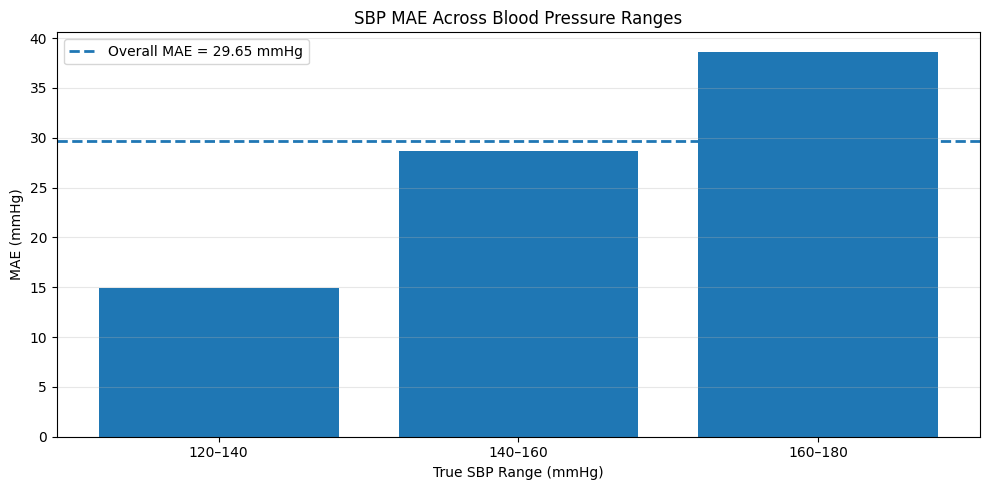


DBP MAE BY TRUE DBP RANGE
20–30 mmHg | Samples:      0 | MAE: N/A
30–40 mmHg | Samples:      0 | MAE: N/A
40–50 mmHg | Samples:      2 | MAE: 20.40 mmHg
50–60 mmHg | Samples:     35 | MAE: 5.24 mmHg
60–70 mmHg | Samples:     35 | MAE: 4.04 mmHg
70–80 mmHg | Samples:     28 | MAE: 8.77 mmHg
80–90 mmHg | Samples:      0 | MAE: N/A
90–100 mmHg | Samples:      0 | MAE: N/A
100–110 mmHg | Samples:      0 | MAE: N/A
110–120 mmHg | Samples:      0 | MAE: N/A
120–130 mmHg | Samples:      0 | MAE: N/A
130–140 mmHg | Samples:      0 | MAE: N/A
140–150 mmHg | Samples:      0 | MAE: N/A


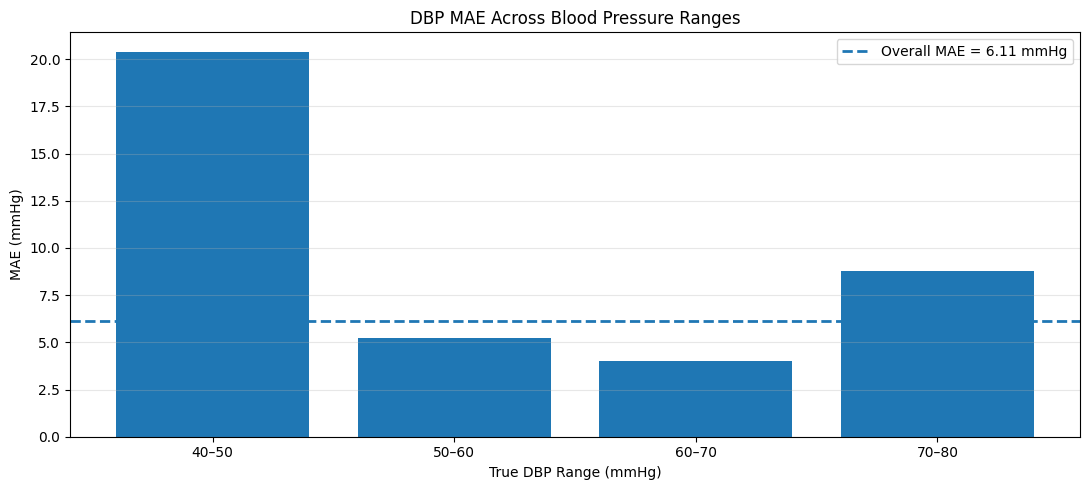

In [48]:
plot_mae(results)